<a href="https://colab.research.google.com/github/jppeirce/DSC210-Foundations-of-Data-Science/blob/main/Notes/12-text_as_data/12-text_as_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 12: Text as Data

**DSC 210 Foundations of Data Science**

References:
- [Hands-on Introduction to Data Science with Python](https://florian-huber.github.io/data_science_course/) (CC BY-NC-SA 4.0)
- [scikit-learn user guide](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction), on text feature extraction
- TripAdvisor hotel reviews (20,491 reviews with star ratings)

```
ASK  ->  GET  ->  EXPLORE  ->  [ MODEL ]  ->  COMMUNICATE
```

*Last major revision: 2026-08-13*

Every dataset so far has been as a table of numbers and categories. Most of the data in the world does not have this format. In this Module, we take 20,491 hotel reviews, written by people in ordinary English, and turn them into something the models from Module 11 can read.

## Key Concepts

- Explain why **unstructured** text has to be converted to numbers before any model can use it
- Clean and **tokenize** raw text, and justify removing **stop words**
- Compute **TF-IDF** by hand on a small corpus, and explain what the IDF term is for
- Build a text classifier using the **logistic regression** from Module 11
- Read a text model's **coefficients** to see which words drive its predictions
- State what the bag-of-words representation throws away, and what **n-grams** partly recover

---
## 1. The Problem With Text
---

Module 2 divided data into **structured** (rows and columns) and **unstructured** (everything else), and put text firmly in the second group. We then spent nine modules exclusively on the first group, because every tool we built needs numbers: a mean needs numbers, a distance needs numbers, a slope needs numbers.

So the whole of this Module reduces to one question:

> **How do we turn "the room was filthy and the staff were rude" into a row of numbers, without throwing away what makes it a complaint?**

The answer will be imperfect, and being clear about *what* gets lost is as important as the technique.

Our data is 20,491 TripAdvisor hotel reviews, each with the reviewer's star rating from 1 to 5.

In [1]:
# RUN-TOGETHER
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

reviews = pd.read_csv('https://raw.githubusercontent.com/jppeirce/DSC210-Foundations-of-Data-Science/main/csv_data/tripadvisor_hotel_reviews.csv')
print(reviews.shape)
print(reviews['Rating'].value_counts().sort_index())
print()
print('one review:')
print(' ', reviews['Review'][0][:220], '...')

(20491, 2)
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

one review:
  nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, b ...


Two things to notice before we do anything clever.

**The ratings are badly imbalanced.** Ratings of 4 and 5 account for about 15,000 of 20,491 reviews. Module 10 told us what to do about that: find the baseline before celebrating any accuracy.

**The text is already partly cleaned.** It is lowercase and stripped of most punctuation. Real text arrives far messier, which is the subject of Section 2.

---
## 2. From Raw Text to Tokens
---
### 2.1 Cleaning

Before text can be counted it has to be made consistent. Three standard steps:

1. **Lowercase everything.** Otherwise `Room`, `room`, and `ROOM` are three different words.
2. **Remove punctuation.** Otherwise `clean.` and `clean` differ.
3. **Split into words.** This is called **tokenization**, and each resulting word is a **token**.

**Definition.** A **token** is one unit of text, usually a word. **Tokenization** is the process of splitting a string into tokens.

In [2]:
# RUN-TOGETHER
raw = "The Room was CLEAN, but the staff were rude!"

lowered = raw.lower()
print('1. lowercased :', lowered)

import re
no_punct = re.sub(r'[^a-z\s]', '', lowered)     # keep letters and spaces only
print('2. depunctuated:', no_punct)

tokens = no_punct.split()
print('3. tokens      :', tokens)
print('   token count :', len(tokens))

1. lowercased : the room was clean, but the staff were rude!
2. depunctuated: the room was clean but the staff were rude
3. tokens      : ['the', 'room', 'was', 'clean', 'but', 'the', 'staff', 'were', 'rude']
   token count : 9


### 2.2 Stop words

Look at those tokens: `the`, `was`, `but`, `were`. They appear in nearly every English sentence and tell you almost nothing about whether a review is positive.

**Definition.** **Stop words** are extremely common words carrying little distinguishing information. Removing them shrinks the data and usually helps.

We will not need to remove them by hand: the tool in Section 3 does it with one argument. But it is worth seeing what is being removed and asking whether it is always safe.

In [3]:
# RUN-TOGETHER
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print('scikit-learn knows', len(ENGLISH_STOP_WORDS), 'English stop words')
print()
print('a sample:', sorted(list(ENGLISH_STOP_WORDS))[:18])
print()
print('kept  :', [t for t in tokens if t not in ENGLISH_STOP_WORDS])
print('removed:', [t for t in tokens if t in ENGLISH_STOP_WORDS])

scikit-learn knows 318 English stop words

a sample: ['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among']

kept  : ['room', 'clean', 'staff', 'rude']
removed: ['the', 'was', 'but', 'the', 'were']


> **Discuss.** The stop word list contains `not`, `no`, and `never`. Removing them turns *"the room was not clean"* into `room clean`, which reads as a compliment. Name one kind of analysis where removing stop words would be actively harmful, and one where it clearly helps.

---
## 3. Turning Words Into Numbers
---
### 3.1 Bag of words

The simplest representation: build a vocabulary of every word in the collection, then give each document one column per word holding a count.

**Definition.** The **bag-of-words** representation records how often each vocabulary word appears in a document, and discards word order entirely. Note: it treats a document as a bag you shake up.

That works, but it has an obvious flaw. In hotel reviews the word `hotel` appears constantly and distinguishes nothing, while `filthy` appears rarely and is enormously informative. Raw counts rank `hotel` as the most important word in the corpus.

### 3.2 TF-IDF

The repair is to weight each word by how *rare* it is across documents.

**Definition.** For a token $t$ in document $d$, drawn from a collection of $N$ documents:

$$\text{term-frequency:} \qquad \text{TF}(t,d) = \frac{\text{count of } t \text{ in } d}{\text{total tokens in } d}
\\
\text{inverse document frequency:} \qquad \text{IDF}(t) = \ln\!\left(\frac{N}{\text{df}(t)}\right)
\\
\text{TF-IDF}(t,d) = \text{TF} \times \text{IDF}$$

where $\text{df}(t)$ is the number of documents containing $t$.

Read the IDF formula before computing anything. If a token appears in **every** document then $\text{df} = N$, so $\ln(N/N) = \ln(1) = 0$, and the token's weight is **zero** no matter how often it occurs. The formula deletes uninformative words automatically.

#### Working one example first

Consider a small collection of just **two** documents.

$$e_1 = \text{"the food was good"} \qquad e_2 = \text{"the food was cold"} \qquad N = 2$$

Each document has 4 tokens and the tokens are only used once in each document, so each token has $\text{TF} = 1/4 = 0.25$.

**Take the token `food`.** It appears in both documents, so $\text{df}(\texttt{food}) = 2$:

$$\text{IDF}(\texttt{food}) = \ln\!\left(\frac{2}{2}\right) = \ln(1) = 0
\qquad\Rightarrow\qquad
\text{TF-IDF}(\texttt{food}, e_1) = 0.25 \times 0 = \mathbf{0}$$

**Now take the token `good`.** It appears in $e_1$ only, so $\text{df}(\texttt{good}) = 1$:

$$\text{IDF}(\texttt{good}) = \ln\!\left(\frac{2}{1}\right) = \ln(2) \approx 0.693
\qquad\Rightarrow\qquad
\text{TF-IDF}(\texttt{good}, e_1) = 0.25 \times 0.693 \approx \mathbf{0.173}$$

The full picture for $e_1$:

| term | df | IDF | TF | TF-IDF |
| --- | --- | --- | --- | --- |
| the | 2 | 0.000 | 0.25 | 0.000 |
| food | 2 | 0.000 | 0.25 | 0.000 |
| was | 2 | 0.000 | 0.25 | 0.000 |
| **good** | **1** | **0.693** | **0.25** | **0.173** |

Three of the four tokens are worth nothing, and the one word that distinguishes this review from the other is the only one that survives. **That is the idea of TF-IDF**, and it is why the representation is useful even though it is only counting.

> **Discuss** What do you think will happen if we computed the TF-IDF for `cold`?

#### **Class Example 12.1 - TF-IDF in code**

In [4]:
# RUN-TOGETHER
from sklearn.feature_extraction.text import TfidfVectorizer

tiny = ["the room was clean",
        "the room was dirty",
        "the staff was great"]

# norm=None and smooth_idf=False make the output match the textbook formula exactly
vec = TfidfVectorizer(norm=None, smooth_idf=False, use_idf=True)
M = vec.fit_transform(tiny)

out = pd.DataFrame(M.toarray(), columns=vec.get_feature_names_out(),
                   index=['d1', 'd2', 'd3']).round(3)
print(out)
print()
print('IDF values scikit-learn used:')
print(pd.Series(vec.idf_, index=vec.get_feature_names_out()).round(3).to_string())

    clean  dirty  great   room  staff  the  was
d1  2.099  0.000  0.000  1.405  0.000  1.0  1.0
d2  0.000  2.099  0.000  1.405  0.000  1.0  1.0
d3  0.000  0.000  2.099  0.000  2.099  1.0  1.0

IDF values scikit-learn used:
clean    2.099
dirty    2.099
great    2.099
room     1.405
staff    2.099
the      1.000
was      1.000


**Note:** `scikit-learn` does not follow the formulas above exactly.

- It uses **raw counts** rather than counts divided by document length, so its numbers will 4 times the result using the formula above. 
    - The *pattern* is what matters, and it matches: `the` and `was` are worth nothing, `room` is worth less than `clean`.

- It also adds 1 to every IDF by default, so a word appearing everywhere gets weight 1 rather than 0. The reason is practical rather than principled: a column of exact zeros is wasted space. 

---
## 4. A Text Classifier
---

We now have everything needed to predict a review's sentiment from its words, and the model will be one you already know.

**The task.** Reviews rated 4 or 5 are **positive**; 1 or 2 are **negative**. We set aside the 3s, which are genuinely ambiguous, and ask: can we tell the two apart from the text alone?

In [5]:
# RUN-TOGETHER
reviews['sentiment'] = np.where(reviews['Rating'] >= 4, 'positive',
                        np.where(reviews['Rating'] <= 2, 'negative', 'neutral'))

print(reviews['sentiment'].value_counts())

binary = reviews[reviews['sentiment'] != 'neutral'].copy()
print()
print('reviews used:', binary.shape[0])
print('baseline (always guess positive):',
      round((binary['sentiment'] == 'positive').mean(), 3))

sentiment
positive    15093
negative     3214
neutral      2184
Name: count, dtype: int64

reviews used: 18307
baseline (always guess positive): 0.824


**Note the baseline: 0.824.** A model that reads nothing and always says "positive" is right 82% of the time. That is the number to beat, and Module 10's fraud example is why we looked for it first.

In [6]:
# RUN-TOGETHER
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    binary['Review'], binary['sentiment'],
    test_size=0.25, random_state=210, stratify=binary['sentiment'])

# Fit the vectorizer on the TRAINING text only. 
tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)

print('documents x vocabulary:', Xtr.shape)

clf = LogisticRegression(max_iter=2000).fit(Xtr, y_train)
print('test accuracy:', round(clf.score(Xte, y_test), 3))

documents x vocabulary: (13730, 2000)
test accuracy: 0.948


**94.8% against an 82.4% baseline.** 

Notice what just happened: `fit_transform` on the training text and `transform` on the test text. Fitting the vectorizer on everything would let test vocabulary leak into training, which is the same rule as the scaler in Module 10, Section 3.2.

### 4.1 Reading the model

The best part of using logistic regression here is that its coefficients are attached to actual words.

In [7]:
# RUN-TOGETHER
coefs = pd.Series(clf.coef_[0], index=tfidf.get_feature_names_out())

print('the 10 words pushing hardest toward POSITIVE:')
print(coefs.nlargest(10).round(2).to_string())
print()
print('the 10 words pushing hardest toward NEGATIVE:')
print(coefs.nsmallest(10).round(2).to_string())

the 10 words pushing hardest toward POSITIVE:
great          8.16
excellent      5.45
loved          5.14
wonderful      4.66
perfect        4.44
fantastic      4.22
comfortable    4.06
helpful        4.00
clean          3.63
friendly       3.40

the 10 words pushing hardest toward NEGATIVE:
worst           -4.68
dirty           -4.51
terrible        -4.41
told            -4.32
rude            -4.25
poor            -4.11
ok              -4.05
horrible        -3.86
bad             -3.39
disappointing   -2.98


Most of these are unsurprising and that is the point: the model has learned what a human would have guessed, from nothing but counts.

One entry is worth noting: **`told` is among the strongest negative words**, and it is not a negative word in English. It is negative here because of *how people write complaints*: "I **told** the front desk three times", "they **told** me nothing could be done." The model has found a narrative pattern, not a sentiment.

> **Discuss.** Is `told` a useful feature or a fragile one? What would happen to this model if it were applied to restaurant reviews, or to reviews written in a different decade?

              precision    recall  f1-score   support

    negative       0.94      0.75      0.83       804
    positive       0.95      0.99      0.97      3773

    accuracy                           0.95      4577
   macro avg       0.94      0.87      0.90      4577
weighted avg       0.95      0.95      0.95      4577



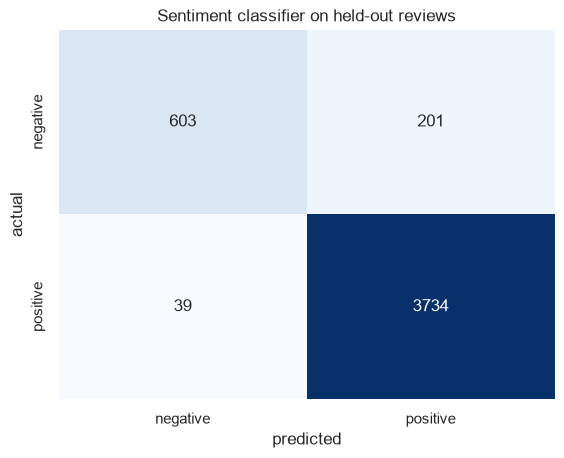

In [8]:
# RUN-TOGETHER
print(classification_report(y_test, clf.predict(Xte)))

cm = confusion_matrix(y_test, clf.predict(Xte), labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('predicted'); plt.ylabel('actual')
plt.title('Sentiment classifier on held-out reviews')
plt.show()

> **Discuss.** Compare the per-class recall. The model is much better at one class than the other. Which one, why, and which Module 10 idea explains it? What would you tell a hotel chain that wanted to use this to flag unhappy guests?

---
## 5. What the Bag Threw Away
---

Bag-of-words discards word order completely. These three reviews produce **identical** vectors:

- *"the room was clean, the service was not good"*
- *"the service was clean, the room was not good"*
- *"not the room, the good service was clean"*

The first two mean different things and the third means almost nothing, yet the model cannot tell them apart.

**N-grams** partially repair this by treating short runs of consecutive words as single terms.

**Definition.** An **n-gram** is a sequence of $n$ consecutive tokens. A **unigram** is one word (`clean`), a **bigram** two (`not clean`), a **trigram** three (`was not clean`).

Bigrams let the model see `not clean` as its own feature, which is exactly the case unigrams get wrong.

In [9]:
# RUN-TOGETHER
tfidf_bi = TfidfVectorizer(stop_words='english', max_features=2000, ngram_range=(1, 2))
Xtr_bi = tfidf_bi.fit_transform(X_train)
Xte_bi = tfidf_bi.transform(X_test)

clf_bi = LogisticRegression(max_iter=2000).fit(Xtr_bi, y_train)
print('unigrams only    :', round(clf.score(Xte, y_test), 3))
print('unigrams + bigrams:', round(clf_bi.score(Xte_bi, y_test), 3))
print()
print('some bigrams that made the vocabulary:')
print([t for t in tfidf_bi.get_feature_names_out() if ' ' in t][:12])

unigrams only    : 0.948
unigrams + bigrams: 0.947

some bigrams that made the vocabulary:
['10 minute', '10 minutes', '15 minute', '15 minutes', '20 minutes', '24 hours', '30 minutes', '3rd floor', 'air conditioned', 'air conditioning', 'airport hotel', 'area hotel']


**Bigrams did not help here** (0.947 against 0.948). 

Why not? The vocabulary was capped at 2,000 features either way, so adding bigrams *pushed out* useful single words to make room. And with reviews this long, enough unigrams like `terrible` and `dirty` survive that word order rarely decides the answer.

**The general lesson:** more features is not better. Every added feature competes for room, and the honest test is whether held-out accuracy moves.

> **Discuss.** Name a text task where word order would matter far more than it does here, and where you would expect bigrams to be more important.

---
## Adding to the Toolkit
---

| Tool | Question it answers | Feature types it needs | Label needed? | Key assumption | How it fails |
| --- | --- | --- | --- | --- | --- |
| **Tokenizing + stop words** | How do I turn a document into countable units? | unstructured text | no | word boundaries are meaningful | destroys negation if `not` is removed; poor on languages without spaces |
| **Bag of words** | How often does each word occur? | text | no | word order does not matter | common words dominate; `not clean` looks like `clean` |
| **TF-IDF** | Which words are distinctive to *this* document? | text | no | rare words are informative | rare typos score highly; still order-blind |
| **N-grams** | Does a short phrase carry more than its words? | text | no | local order is what matters | vocabulary explodes; competes with unigrams for feature budget |
| **TF-IDF + logistic regression** | Which category does this document belong to? | text plus a categorical label | **yes** | the words present are enough | learns corpus quirks (`told`); transfers poorly to other domains |

**Notice the "Label needed?" column.** Everything that turns text into numbers is **unsupervised**: it needs no labels at all, and belongs to the GET and EXPLORE stages. Only the last row is a model. Text processing is mostly data preparation wearing an intimidating name.

## Suggested Exercises

1. A collection of four short documents:

    $d_1$ = "data science is fun", $d_2$ = "science is hard", $d_3$ = "data is everywhere", $d_4$ = "fun fun fun"

    a. Build the vocabulary and compute df and IDF for every term, using $\ln(N/\text{df})$.

    b. Compute the full TF-IDF vector for $d_4$. (Careful: `fun` appears three times out of three tokens.)

    c. Which term has the highest IDF, and which the lowest? Explain both in one sentence each.

    d. Explain why `is` will be useless for any classifier built on this collection, without referring to a stop word list.

2. A classifier trained on movie reviews reaches 91% accuracy. The test set is 88% positive reviews.

    a. What is the baseline, and how impressive is 91% against it?

    b. Which single table from Module 10 would you ask to see next, and what would you look for in it?

    c. The model's most negative word is `unfortunately`. Is that a sentiment word or a narrative-pattern word? Compare with the `told` example from Section 4.1.

    d. The team wants to reuse this model on *product* reviews. Give two specific reasons its accuracy will drop.

3. You are asked to classify 5,000 support emails as urgent or routine.

    a. List the preprocessing steps you would apply, in order, and say why each one comes where it does.

    b. Would you remove stop words here? Argue both sides, using the `not` example from Section 2.2.

    c. Urgent emails are 6% of the data. Name the problem this creates and one thing you would do about it.

    d. Which metric from Module 10 would you optimize, and why does the answer depend on what happens to a missed urgent email?

4. A colleague reports that adding trigrams raised training accuracy from 0.94 to 0.99 and lowered test accuracy from 0.93 to 0.89.

    a. Name the phenomenon.

    b. Explain the mechanism specifically in terms of what trigrams do to the vocabulary.

    c. Your colleague proposes fixing it by adding more trigrams. Explain why that will make it worse.

    d. Give two changes that would genuinely help, and say which module each comes from.